# Clean data:
 - remove description column

In [11]:
# path: data/victims.csv
# post_title,group_name,discovered,description,published,post_url,country,activity,website,duplicates
# Afpa,doppelpaymer,2020-04-17 00:00:00.000000,,2020-04-17 00:00:00.000000,,FR,Education,afpa.fr,[]
# IKEA Morocco IKEA Kuwait,vicesociety,2022-11-28 03:38:07.62290,"We believe that no matter what we do in life, we should always try to be the absolute best at it. At IKEA we focus on being the best at ordinary everyday things. Because to us, the ordinary everyday contains the best of life. We want to be Extraordinary at the ordinary for you.",2022-11-28 03:38:07.62290,,,,,[]

import pandas as pd
# Load the CSV file into a DataFrame
df = pd.read_csv('data/victims.csv')
# remove description, duplicates, post_url, discovered, column
df = df.drop(columns=['description', 'duplicates', 'post_url', 'discovered'])
# Save the cleaned DataFrame back to a new CSV file

# select only rows where website is not null
df = df[df['website'].notna()]
# remove rows if in website column are present quotes
df = df[~df['website'].str.contains('"')]

# select only attacks from 2020 and later
df['published'] = pd.to_datetime(df['published'], errors='coerce')
df = df[df['published'] >= pd.to_datetime('2020-01-01')]
# adjust published column normalize to YYYY-MM-DD format
df['published'] = df['published'].dt.strftime('%Y-%m-%d')

# remove post_title column
df = df.drop(columns=['post_title'])

# save in utf8

df.to_csv('data/victims_cleaned.csv', index=False, encoding='utf-8')


# Ransomware.live couting

In [12]:
# path: data/victims.csv
# post_title,group_name,discovered,description,published,post_url,country,activity,website,duplicates
# Afpa,doppelpaymer,2020-04-17 00:00:00.000000,,2020-04-17 00:00:00.000000,,FR,Education,afpa.fr,[]
# IKEA Morocco IKEA Kuwait,vicesociety,2022-11-28 03:38:07.62290,"We believe that no matter what we do in life, we should always try to be the absolute best at it. At IKEA we focus on being the best at ordinary everyday things. Because to us, the ordinary everyday contains the best of life. We want to be Extraordinary at the ordinary for you.",2022-11-28 03:38:07.62290,,,,,[]


import pandas as pd
# importing ploting the data
import matplotlib.pyplot as plt
victims = pd.read_csv('data/victims.csv')
# find first attack when happened
first_attack = victims['discovered'].min()
print(f"First attack discovered on: {first_attack}")
last_attack = victims['discovered'].max()
print(f"Last attack discovered on: {last_attack}")

# total number of victims
total_victims = victims.shape[0]
print(f"Total number of victims: {total_victims}")

# total groups
total_groups = victims['group_name'].nunique()
print(f"Total number of groups: {total_groups}")

# top 10 groups by number of victims
top_groups = victims['group_name'].value_counts().head(10)
print("Top 10 groups by number of victims:")
print(top_groups)

# most active groups by year
victims['year'] = pd.to_datetime(victims['discovered']).dt.year
active_groups_by_year = victims.groupby(['year', 'group_name']).size().unstack(fill_value=0)
print("Most active groups by year:")
print(active_groups_by_year)

# attacks by year
attacks_by_year = victims.groupby('year').size()
print("Attacks by year:")
print(attacks_by_year)



First attack discovered on: 2013-11-06 00:00:00.000000
Last attack discovered on: 2026-02-05 15:09:46.848580
Total number of victims: 25430
Total number of groups: 298
Top 10 groups by number of victims:
group_name
lockbit3     2017
qilin        1427
akira        1304
clop         1172
play         1151
lockbit2     1006
ransomhub     844
alphv         731
incransom     653
bianlian      553
Name: count, dtype: int64
Most active groups by year:
group_name  0mega  8base  BrainCipher  ElDorado  GDLockerSec  IMNCrew   J  RunSomeWares  SilentRansomGroup  ValenciaLeaks  VanHelsing  abyss  agelocker  akira  alphalocker  alphv  anubis  apos  apt73  arcusmedia  argonauts  arkana  arvinclub  astroteam  atomsilo  avaddon  avoslocker  azroteam  babuk  babuk2  beast  benzona  bert  bianlian  bitlocker  bitpaymer  blackbasta  blackbyte  blacklock  blackmatter  blacknevas  blackout  blackshadow  blackshrantac  blacksuit  blacktor  blogxx  bluebox  bonacigroup  bqtlock  brotherhood  cactus  cephalus 

# Plots

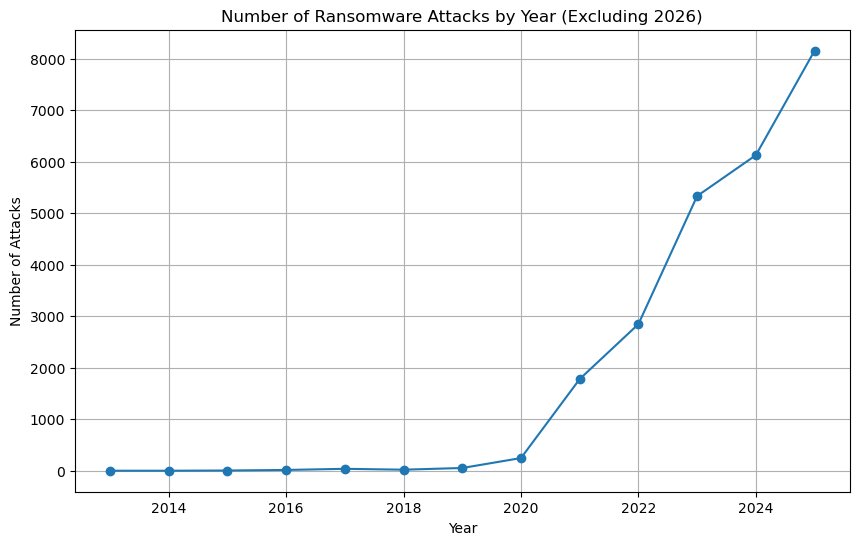

Number of attacks by year (excluding 2026):
year
2013       2
2014       2
2015       6
2016      17
2017      39
2018      22
2019      55
2020     248
2021    1782
2022    2849
2023    5336
2024    6129
2025    8158
dtype: int64


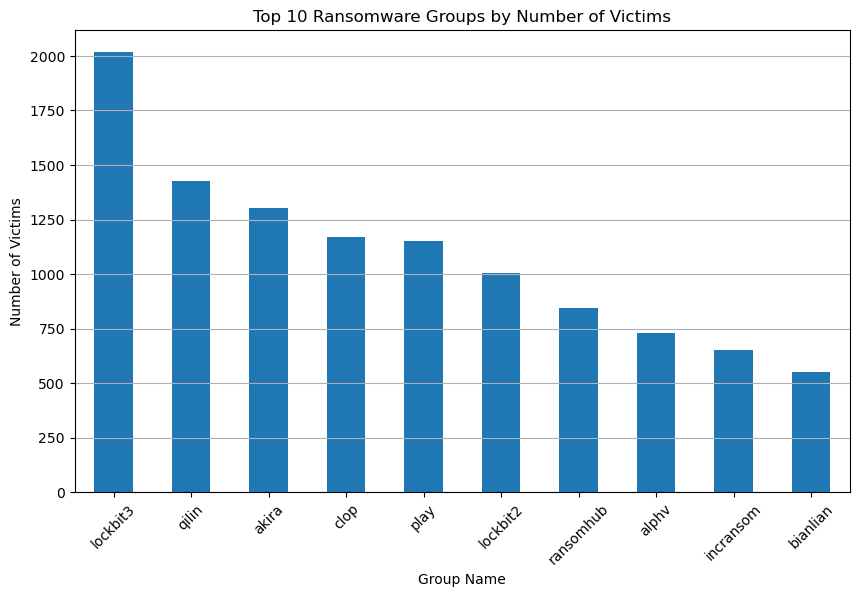

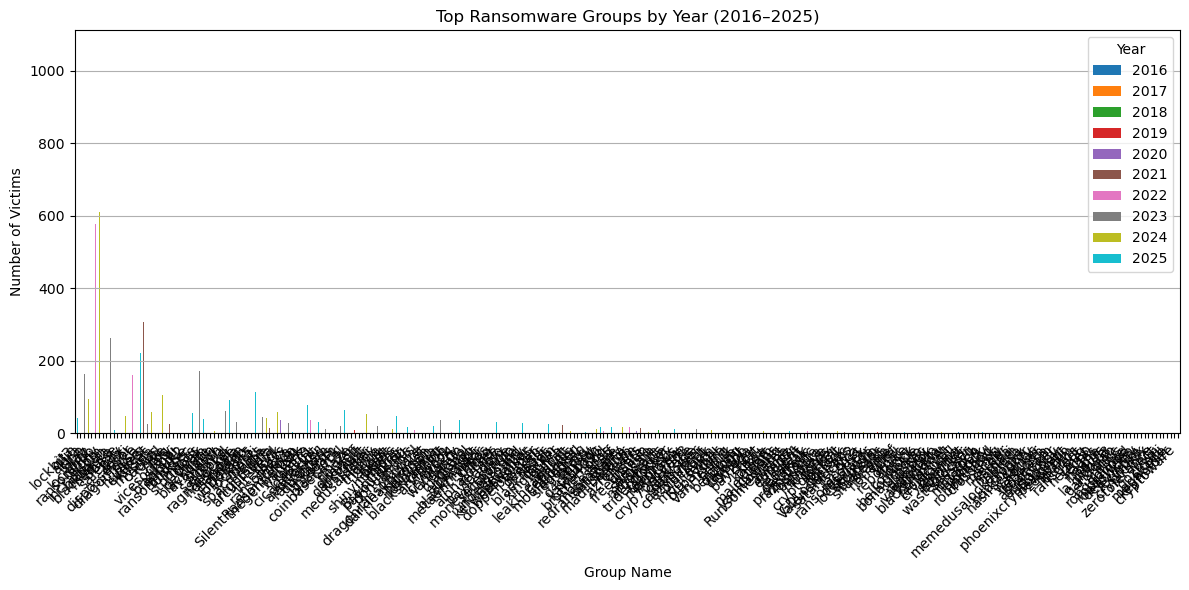

year        2016  2017  2018  2019  2020  2021  2022  2023  2024  2025
group_name                                                            
lockbit3       0     0     0     0     0     0   394  1045   537    41
qilin          0     0     0     0     0     0     1    50   186  1058
akira          0     0     0     0     0     0     0   163   317   750
clop           0     0     0     0     4     0   122   389    93   518
play           0     0     0     0     0     0    36   318   367   391
...          ...   ...   ...   ...   ...   ...   ...   ...   ...   ...
goznym         0     0     0     0     0     0     0     0     0     0
sicarii        0     0     0     0     0     0     0     0     0     0
megacode       0     0     0     0     0     0     0     0     0     0
keyholder      0     0     0     0     0     0     0     0     0     0
cryptoware     0     0     0     0     0     0     0     0     0     0

[298 rows x 10 columns]


In [13]:
import matplotlib.pyplot as plt

# plot all the data, exclude 2026


plt.figure(figsize=(10, 6))
attacks_by_year_filtered = attacks_by_year[attacks_by_year.index != 2026]
plt.plot(attacks_by_year_filtered.index, attacks_by_year_filtered.values, marker='o')
plt.title('Number of Ransomware Attacks by Year (Excluding 2026)')
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.grid()
plt.show()

# print num attacks
print("Number of attacks by year (excluding 2026):")
print(attacks_by_year_filtered)

# plot top 10 groups
plt.figure(figsize=(10, 6))
top_groups.plot(kind='bar')
plt.title('Top 10 Ransomware Groups by Number of Victims')
plt.xlabel('Group Name')
plt.ylabel('Number of Victims')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

import matplotlib.pyplot as plt

years = list(range(2016, 2026))

# Option A: choose a consistent set of groups across all years (top 10 overall in 2020-2025)
top_groups = (
    active_groups_by_year.loc[years]   # keep only those years
    .stack()                           # (year, group) -> value
    .groupby(level=1).sum()            # sum per group across years
    .nlargest(6000)
    .index
)

# Build a matrix: index=group, columns=year
df = active_groups_by_year.loc[years, top_groups].T  # transpose so groups are rows

ax = df.plot(kind="bar", figsize=(12, 6))  # grouped bars automatically
ax.set_title("Top Ransomware Groups by Year (2016–2025)")
ax.set_xlabel("Group Name")
ax.set_ylabel("Number of Victims")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.legend(title="Year")
plt.tight_layout()
plt.show()

# print table using pandas for index=group, columns=year
print(df)

# create file: group_activity_by_year.csv with index=group, columns=year, remove groups that all yras are 0

df_filtered = df.loc[~(df == 0).all(axis=1)]  # Remove rows (groups) where all years are 0
df_filtered.to_csv('output/groups_activity_by_year.csv')

# Plot By Quarter

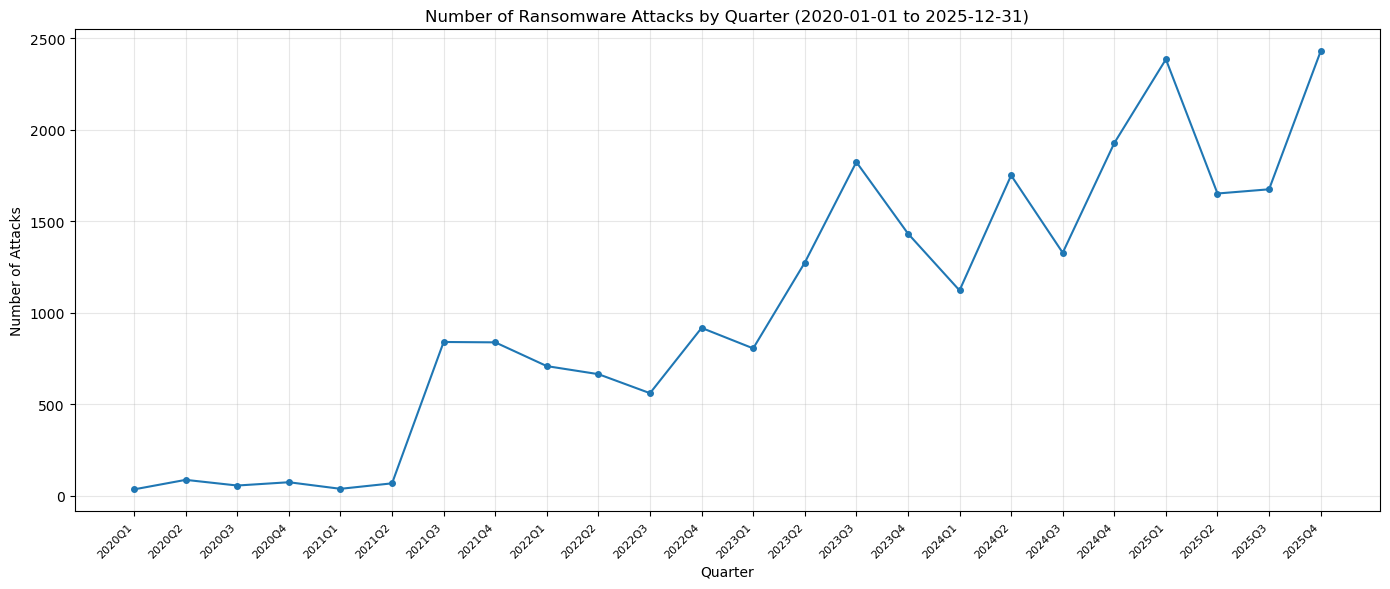

Number of attacks by quarter (2020-01-01 to 2025-12-31):
year_quarter
2020Q1      34
2020Q2      86
2020Q3      55
2020Q4      73
2021Q1      37
2021Q2      67
2021Q3     840
2021Q4     838
2022Q1     708
2022Q2     664
2022Q3     560
2022Q4     917
2023Q1     805
2023Q2    1274
2023Q3    1824
2023Q4    1433
2024Q1    1122
2024Q2    1751
2024Q3    1328
2024Q4    1928
2025Q1    2386
2025Q2    1652
2025Q3    1675
2025Q4    2430
Freq: Q-DEC, dtype: int64


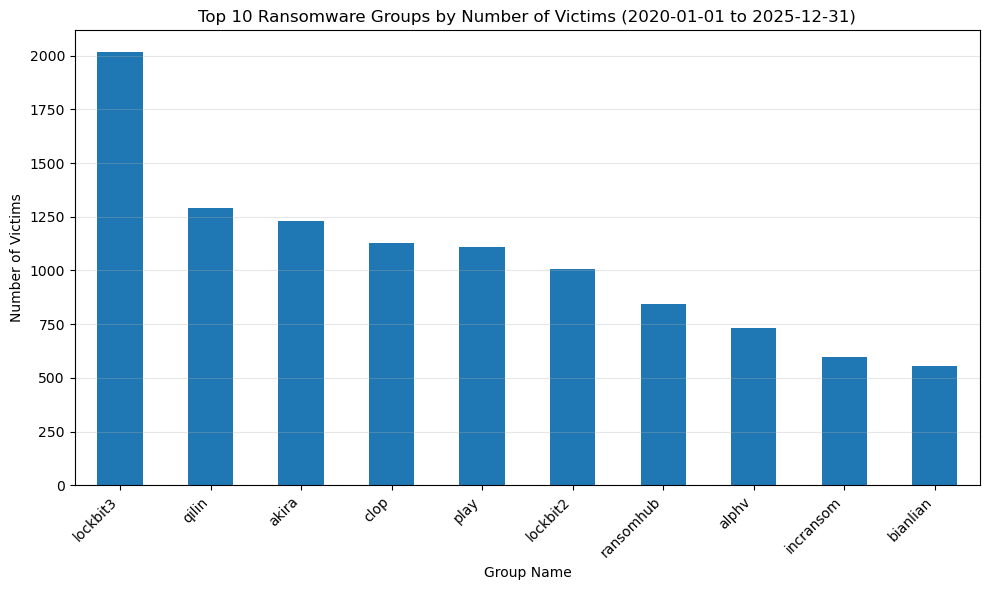

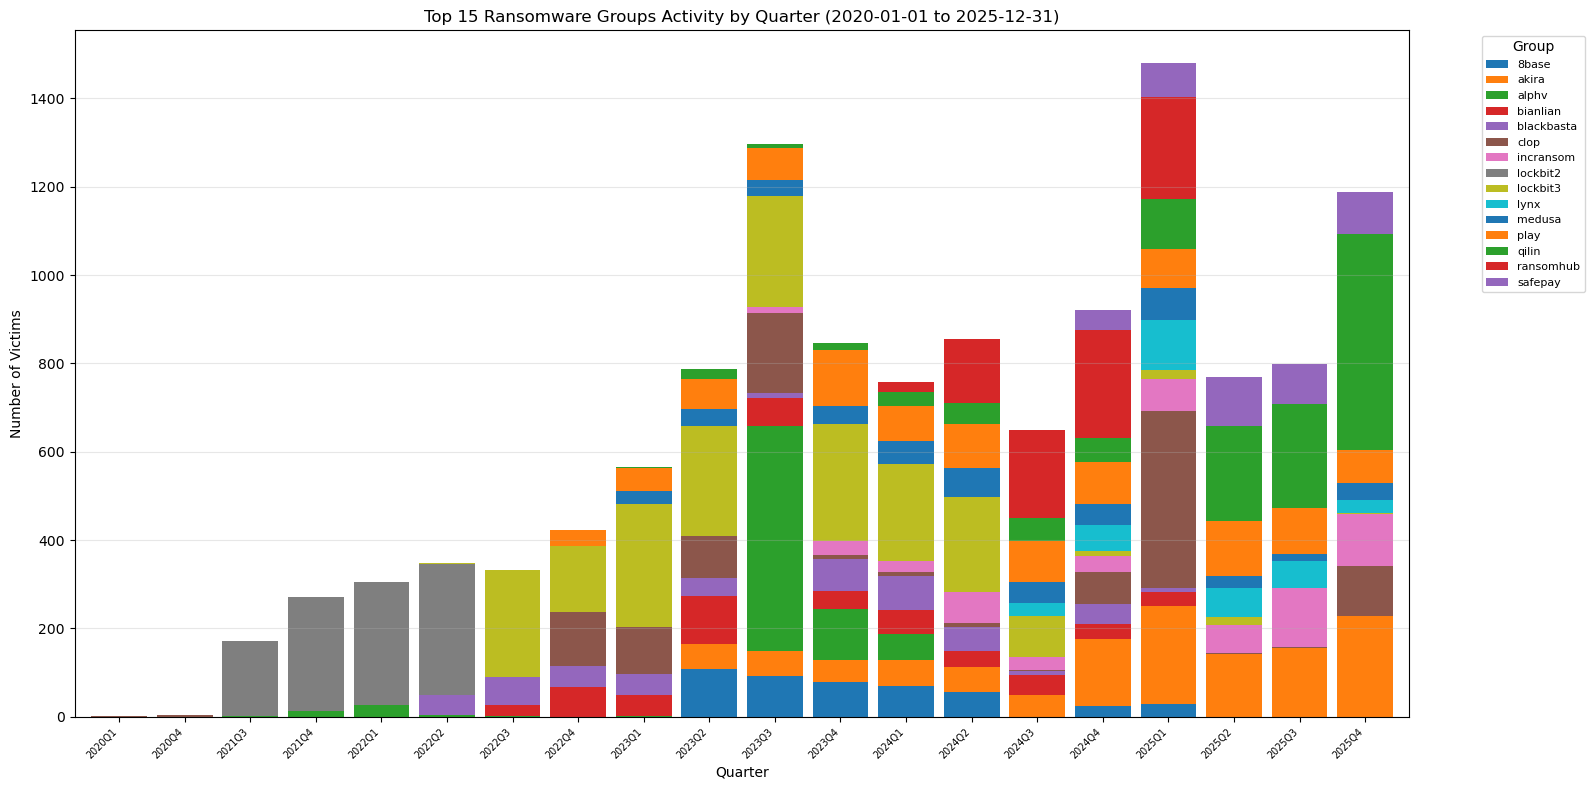


Saved: 270 groups x 24 quarters


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# === CONFIGURE DATE RANGE ===
START_DATE = '2020-01-01'
END_DATE = '2025-12-31'

# Load data
victims = pd.read_csv('data/victims.csv')
victims['discovered'] = pd.to_datetime(victims['discovered'])

# Filter by date range
victims = victims[(victims['discovered'] >= START_DATE) & (victims['discovered'] <= END_DATE)]

victims['year'] = victims['discovered'].dt.year
victims['quarter'] = victims['discovered'].dt.quarter
victims['year_quarter'] = victims['discovered'].dt.to_period('Q')

# --- 1. Attacks by Quarter (line plot) ---
attacks_by_quarter = victims.groupby('year_quarter').size()

plt.figure(figsize=(14, 6))
x_labels = [str(q) for q in attacks_by_quarter.index]
plt.plot(range(len(x_labels)), attacks_by_quarter.values, marker='o', linewidth=1.5, markersize=4)
plt.title(f'Number of Ransomware Attacks by Quarter ({START_DATE} to {END_DATE})')
plt.xlabel('Quarter')
plt.ylabel('Number of Attacks')
plt.xticks(range(len(x_labels)), x_labels, rotation=45, ha='right', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Number of attacks by quarter ({START_DATE} to {END_DATE}):")
print(attacks_by_quarter)

# --- 2. Top 10 Groups bar chart ---
top_groups = victims['group_name'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_groups.plot(kind='bar')
plt.title(f'Top 10 Ransomware Groups by Number of Victims ({START_DATE} to {END_DATE})')
plt.xlabel('Group Name')
plt.ylabel('Number of Victims')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# --- 3. Top groups activity by quarter (stacked bar) ---
top_n = 15
top_group_names = victims['group_name'].value_counts().head(top_n).index
filtered = victims[victims['group_name'].isin(top_group_names)]

activity_by_quarter = filtered.groupby(['year_quarter', 'group_name']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(16, 8))
activity_by_quarter.plot(kind='bar', stacked=True, ax=ax, width=0.85)
ax.set_title(f'Top {top_n} Ransomware Groups Activity by Quarter ({START_DATE} to {END_DATE})')
ax.set_xlabel('Quarter')
ax.set_ylabel('Number of Victims')
ax.set_xticklabels([str(q) for q in activity_by_quarter.index], rotation=45, ha='right', fontsize=7)
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# --- 4. All groups activity by quarter → CSV ---
all_activity = victims.groupby(['year_quarter', 'group_name']).size().unstack(fill_value=0)
df_out = all_activity.T
df_out.columns = [str(c) for c in df_out.columns]
df_out = df_out.loc[~(df_out == 0).all(axis=1)]
df_out.to_csv('output/groups_activity_by_quarter.csv')

print(f"\nSaved: {df_out.shape[0]} groups x {df_out.shape[1]} quarters")

# Most active groups by year

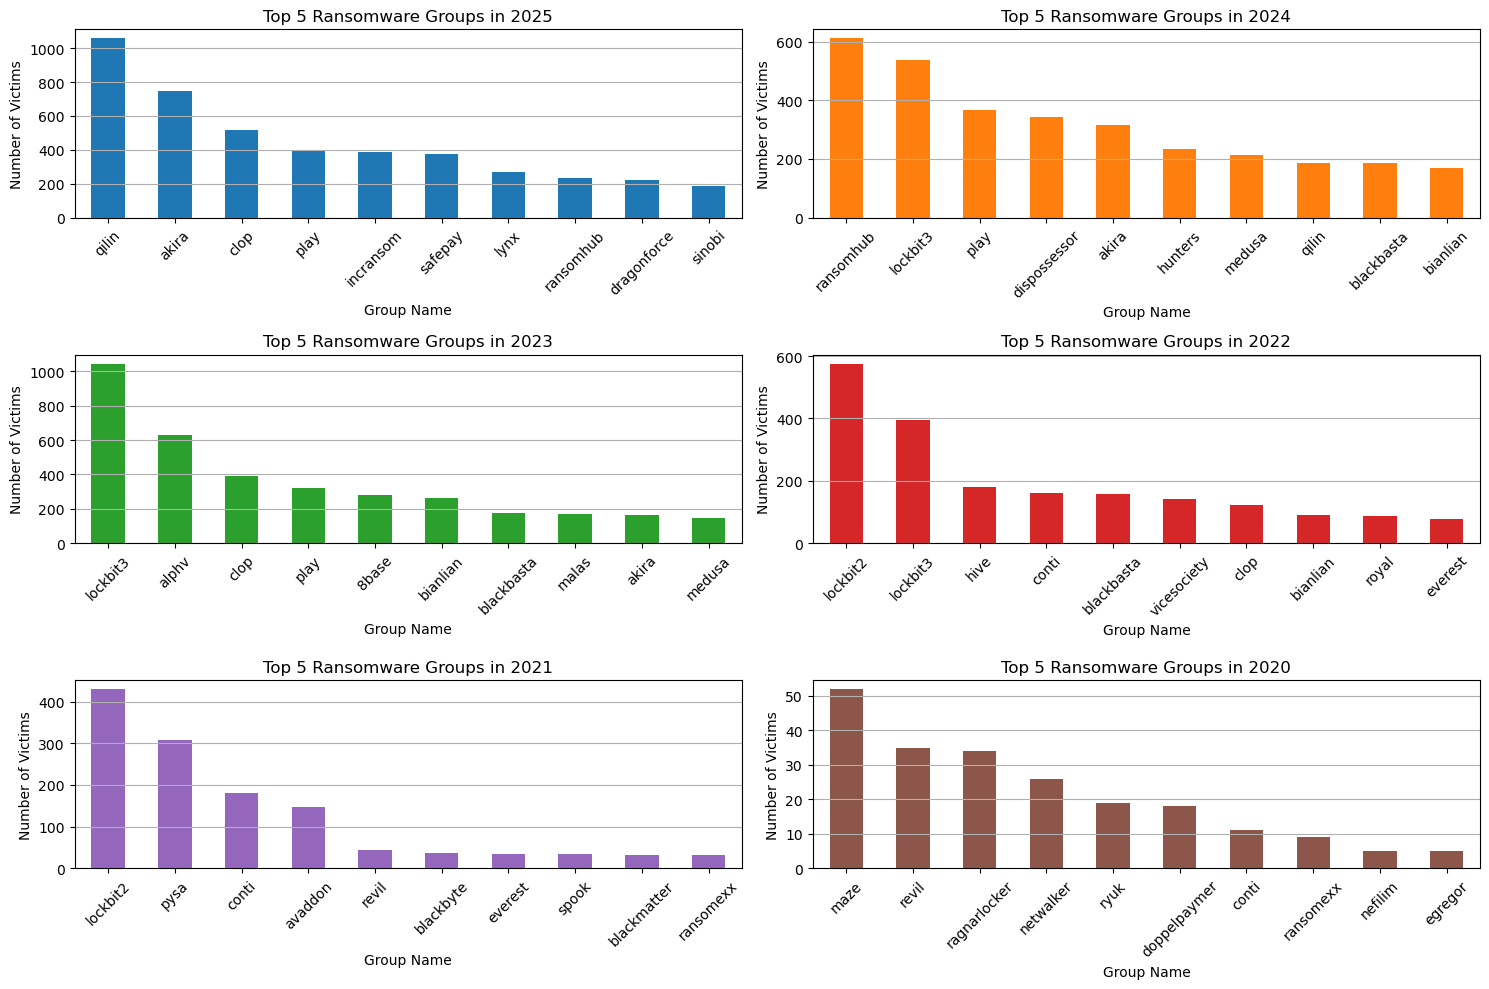

In [ ]:
# path: data/victims.csv
# post_title,group_name,discovered,description,published,post_url,country,activity,website,duplicates
# Afpa,doppelpaymer,2020-04-17 00:00:00.000000,,2020-04-17 00:00:00.000000,,FR,Education,afpa.fr,[]
# IKEA Morocco IKEA Kuwait,vicesociety,2022-11-28 03:38:07.62290,"We believe that no matter what we do in life, we should always try to be the absolute best at it. At IKEA we focus on being the best at ordinary everyday things. Because to us, the ordinary everyday contains the best of life. We want to be Extraordinary at the ordinary for you.",2022-11-28 03:38:07.62290,,,,,[]


# plot top 5 most active groups by year in each year: 2025, 2024, 2023, 2022, 2021, 2020, do it in one mosaic plot with different colors for each year
years = [2025, 2024, 2023, 2022, 2021, 2020]
plt.figure(figsize=(15, 10))
for i, year in enumerate(years):
    plt.subplot(3, 2, i+1)
    top_groups_year = active_groups_by_year.loc[year].sort_values(ascending=False).head(10)
    top_groups_year.plot(kind='bar', color=plt.cm.tab10(i))
    plt.title(f'Top 5 Ransomware Groups in {year}')
    plt.xlabel('Group Name')
    plt.ylabel('Number of Victims')
    plt.xticks(rotation=45)
    plt.grid(axis='y')
plt.tight_layout()
plt.show()



# Groups by sector

# create a mosaic plot for 2022 with groups and sectors

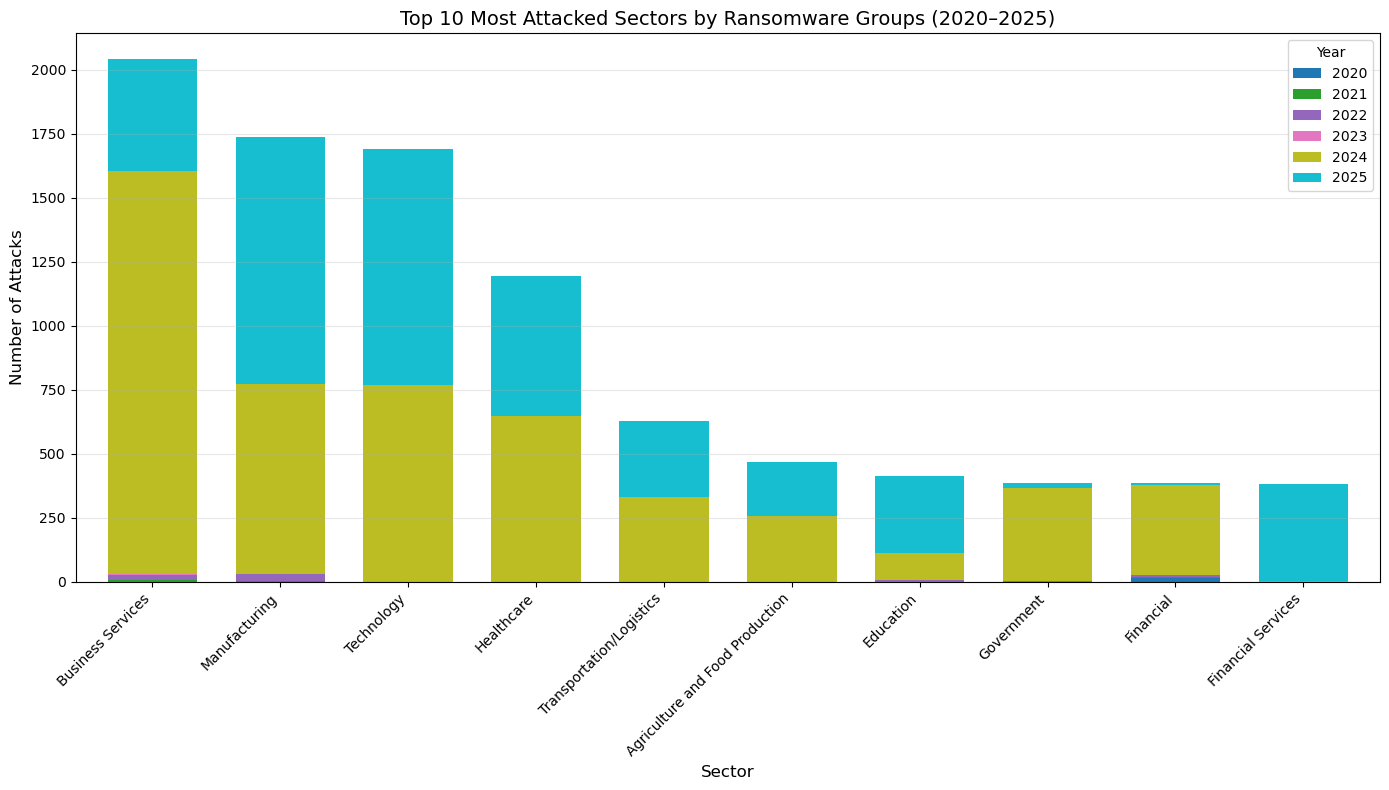

In [49]:
import matplotlib.pyplot as plt
import pandas as pd

# Filter years 2020-2025
years = range(2020, 2026)
victims_filtered = victims[victims['year'].isin(years)]

# Remove "Not Found" and blank sectors
victims_filtered = victims_filtered[
    (victims_filtered['activity'] != 'Not Found') & 
    (victims_filtered['activity'] != '') & 
    (victims_filtered['activity'].notna())
]

# Count attacks per sector per year
sector_year = victims_filtered.groupby(['activity', 'year']).size().unstack(fill_value=0)

# Get top 10 sectors by total attacks
top_10_sectors = sector_year.sum(axis=1).sort_values(ascending=False).head(10).index
sector_year_top = sector_year.loc[top_10_sectors]

# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(14, 8))
sector_year_top.plot(kind='bar', ax=ax, stacked=True, width=0.7, colormap='tab10')

ax.set_title('Top 10 Most Attacked Sectors by Ransomware Groups (2020–2025)', fontsize=14)
ax.set_xlabel('Sector', fontsize=12)
ax.set_ylabel('Number of Attacks', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(title='Year', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

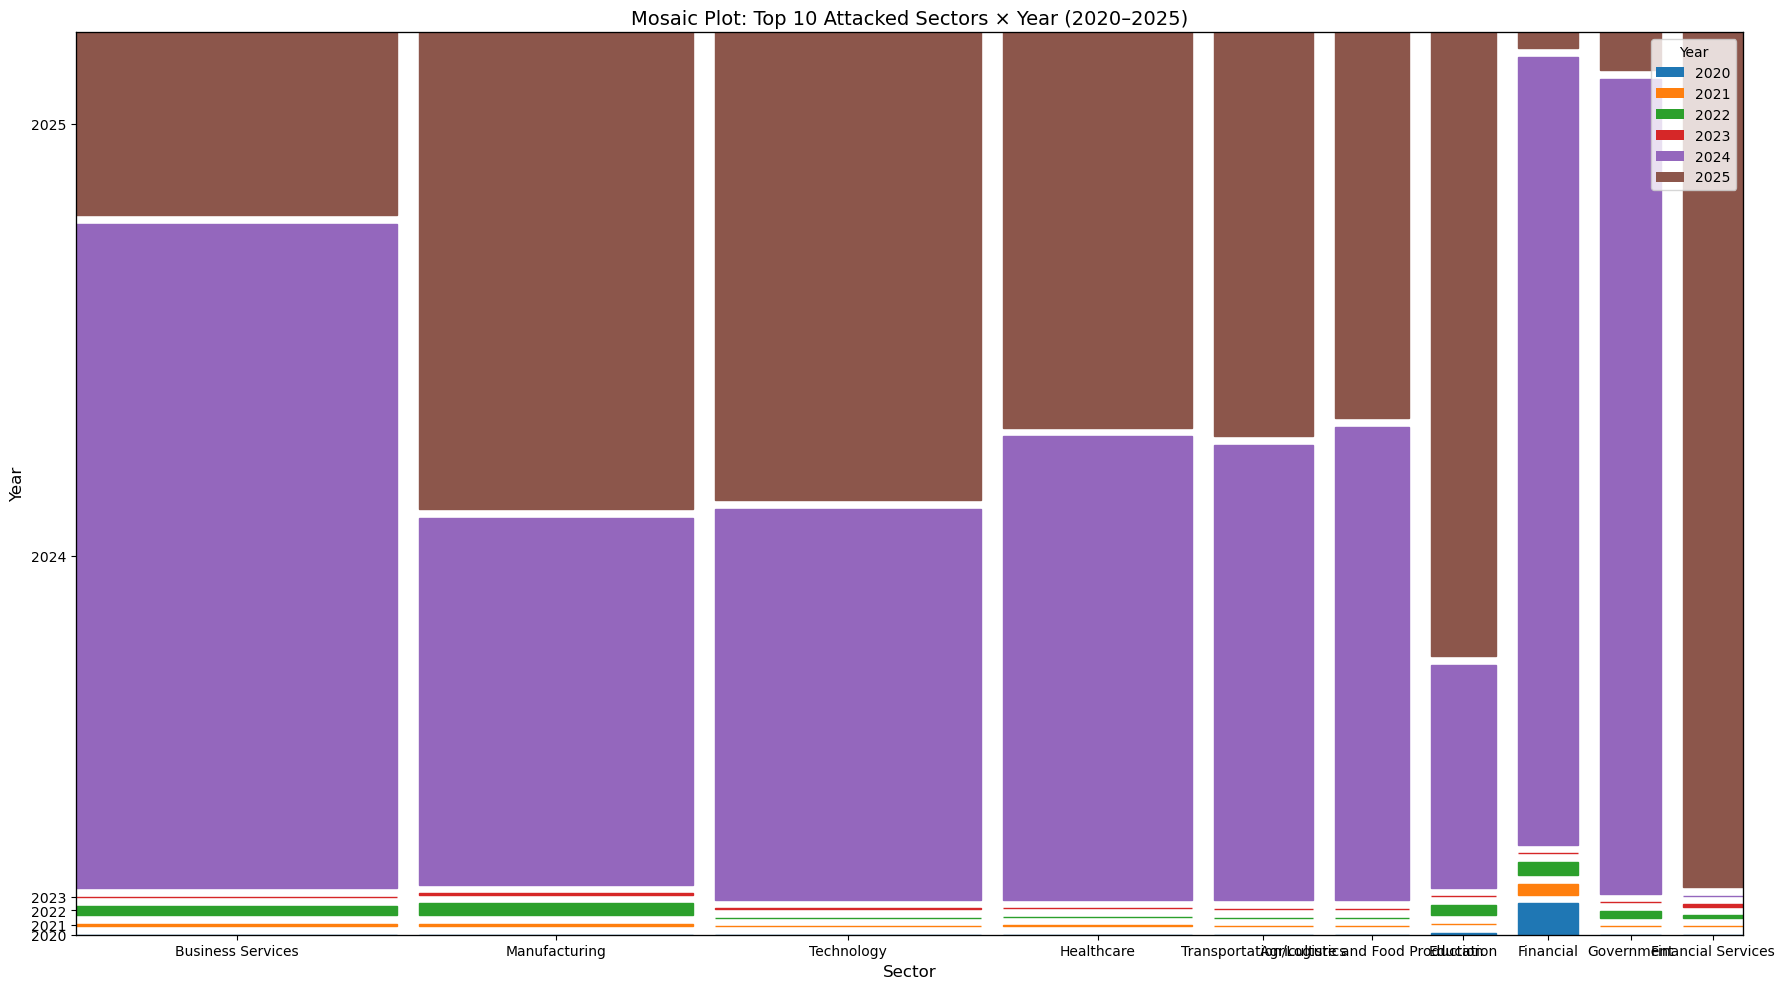

In [50]:
from statsmodels.graphics.mosaicplot import mosaic
import matplotlib.pyplot as plt
import pandas as pd

# Filter years 2020-2025
years = range(2020, 2026)
victims_filtered = victims[victims['year'].isin(years)]

# Remove "Not Found" and blank sectors
victims_filtered = victims_filtered[
    (victims_filtered['activity'] != 'Not Found') & 
    (victims_filtered['activity'] != '') & 
    (victims_filtered['activity'].notna())
]

# Keep only top 10 sectors
top_10 = victims_filtered['activity'].value_counts().head(10).index
victims_top = victims_filtered[victims_filtered['activity'].isin(top_10)].copy()
victims_top['year'] = victims_top['year'].astype(str)

# Create contingency table
ct = pd.crosstab(victims_top['activity'], victims_top['year'])
# Sort by total descending
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]

# Build tuples for mosaic
data = {}
for sector in ct.index:
    for year in ct.columns:
        data[(sector, year)] = ct.loc[sector, year]

# Color map: one color per year
year_colors = {
    '2020': '#1f77b4',
    '2021': '#ff7f0e', 
    '2022': '#2ca02c',
    '2023': '#d62728',
    '2024': '#9467bd',
    '2025': '#8c564b'
}

def props(key):
    return {'color': year_colors.get(key[1], '#333333')}

fig, ax = plt.subplots(figsize=(18, 10))
mosaic(data, ax=ax, properties=props, labelizer=lambda k: '', gap=0.015)

ax.set_title('Mosaic Plot: Top 10 Attacked Sectors × Year (2020–2025)', fontsize=14)
ax.set_xlabel('Sector', fontsize=12)
ax.set_ylabel('Year', fontsize=12)

# Manual legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=y) for y, c in year_colors.items()]
ax.legend(handles=legend_elements, title='Year', loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

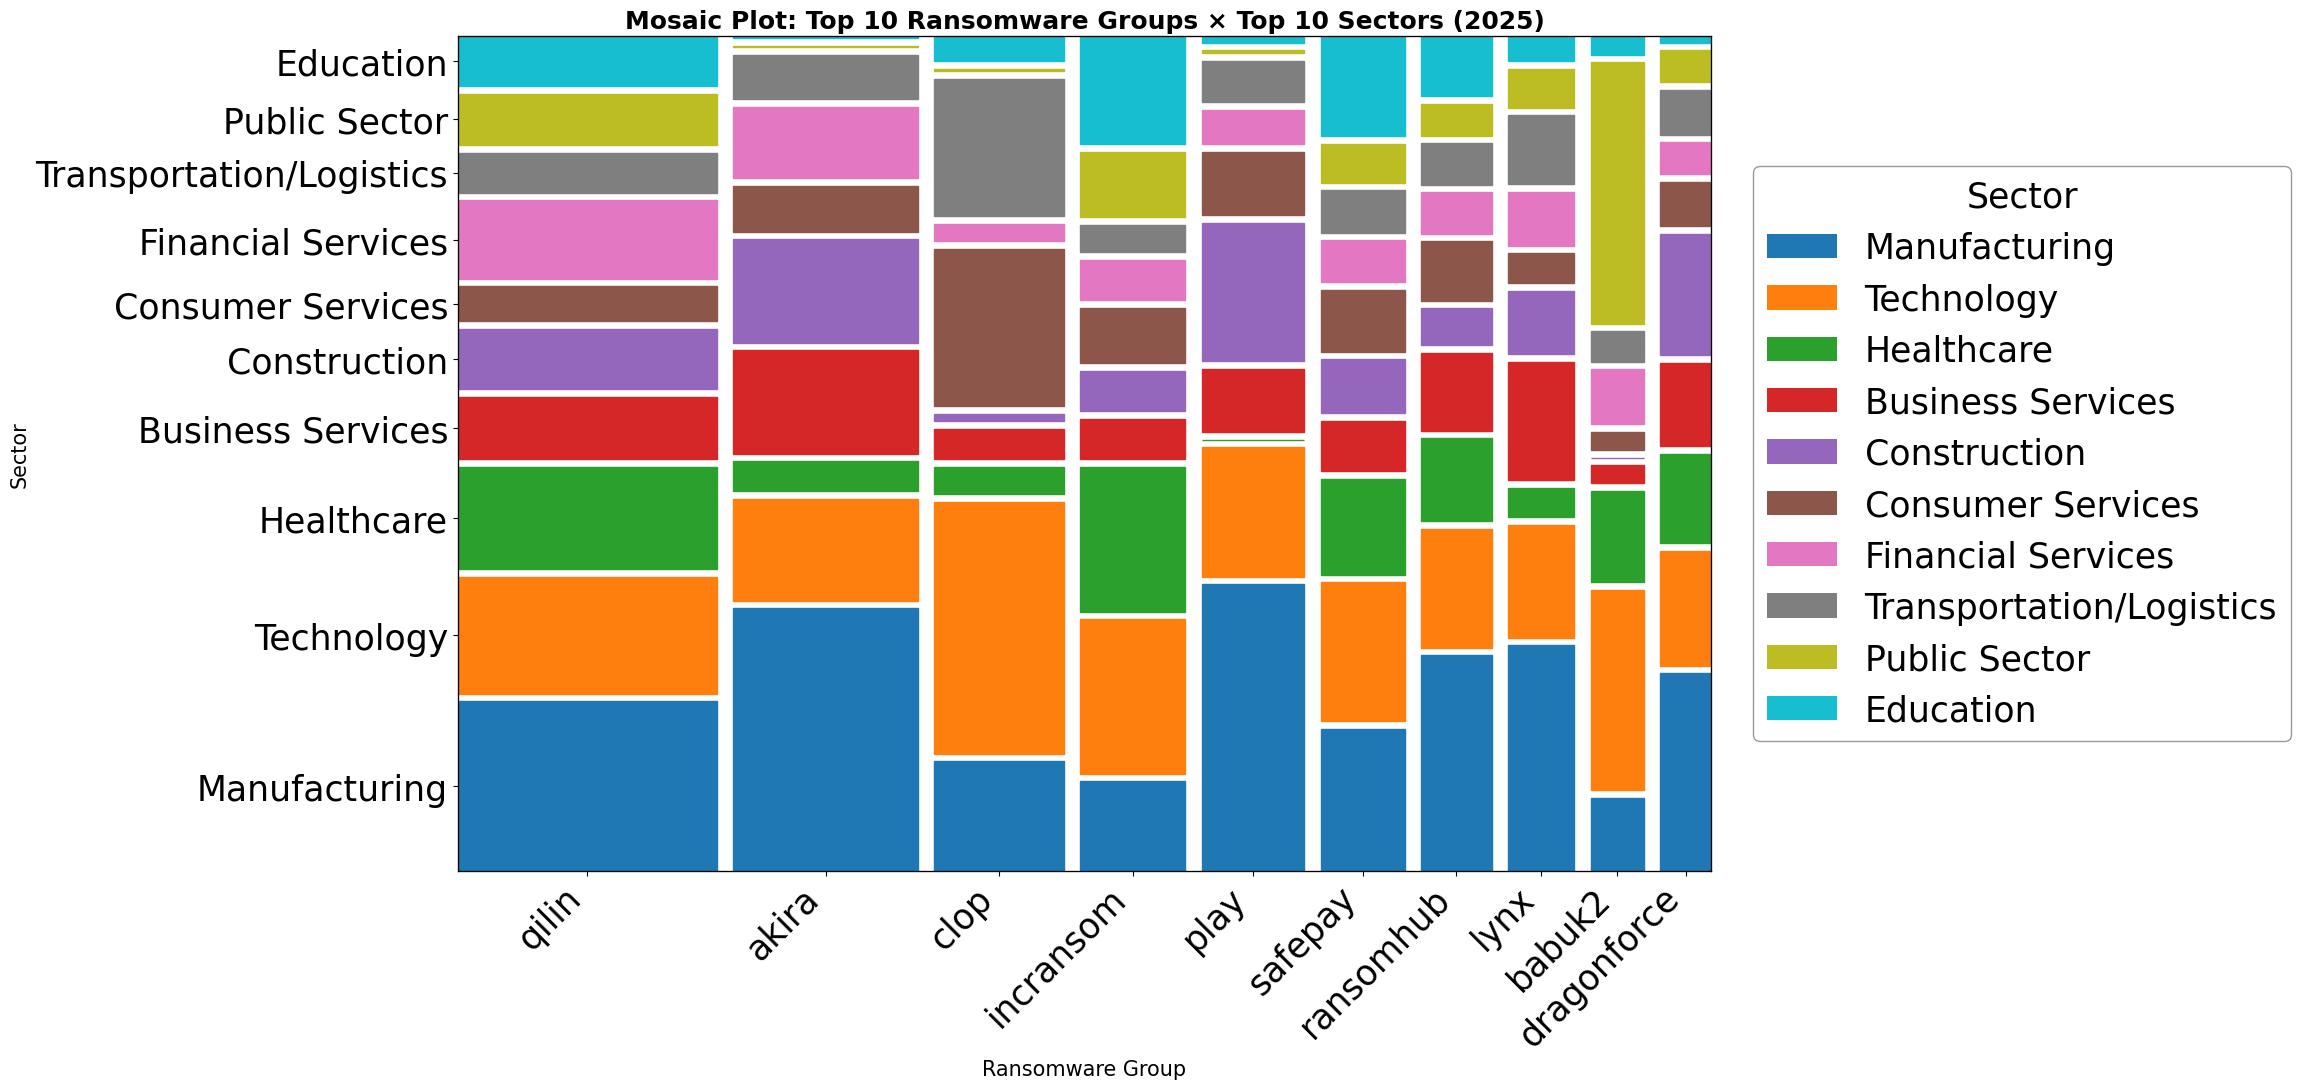

In [76]:
from statsmodels.graphics.mosaicplot import mosaic
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch

# Filter 2025
victims_2025 = victims[victims['year'] == 2025].copy()

# Remove blank/Not Found sectors
victims_2025 = victims_2025[
    (victims_2025['activity'] != 'Not Found') & 
    (victims_2025['activity'] != '') & 
    (victims_2025['activity'].notna())
]

# Top 10 groups and top 10 sectors
top_10_groups = victims_2025['group_name'].value_counts().head(10).index
top_10_sectors = victims_2025['activity'].value_counts().head(10).index

victims_top = victims_2025[
    (victims_2025['group_name'].isin(top_10_groups)) & 
    (victims_2025['activity'].isin(top_10_sectors))
].copy()

# Contingency table: groups x sectors
ct = pd.crosstab(victims_top['group_name'], victims_top['activity'])
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]
ct = ct[ct.sum().sort_values(ascending=False).index]

# Build mosaic data
data = {}
for group in ct.index:
    for sector in ct.columns:
        data[(group, sector)] = ct.loc[group, sector]

# Color map per sector
colors = plt.cm.tab10.colors
sector_list = list(ct.columns)
sector_colors = {s: colors[i % len(colors)] for i, s in enumerate(sector_list)}

def props(key):
    return {'color': sector_colors.get(key[1], '#333333')}

fig, ax = plt.subplots(figsize=(22, 11))
mosaic(data, ax=ax, properties=props, labelizer=lambda k: '', gap=0.015)

ax.set_title('Mosaic Plot: Top 10 Ransomware Groups × Top 10 Sectors (2025)', fontsize=18, fontweight='bold')
ax.set_xlabel('Ransomware Group', fontsize=15)
ax.set_ylabel('Sector', fontsize=15)

# Rotate x-axis labels 45 degrees
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=25)
ax.tick_params(axis='y', labelsize=25)

# Legend outside plot
legend_elements = [Patch(facecolor=sector_colors[s], label=s) for s in sector_list]
ax.legend(
    handles=legend_elements, 
    title='Sector', 
    loc='center left', 
    bbox_to_anchor=(1.02, 0.5),
    fontsize=25, 
    title_fontsize=25,
    frameon=True,
    edgecolor='gray'
)

plt.tight_layout()
plt.subplots_adjust(right=0.78)
plt.show()

In [1]:
#!/usr/bin/env python3
"""
Odds Ratio Analysis: Ransomware Groups vs Sectors (2025)

Calculates odds ratios with p-values for each ransomware group and sector 
combination to identify targeting patterns.
"""

import pandas as pd
import numpy as np
from scipy.stats import fisher_exact
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')


def load_and_filter_data(filepath: str, year_start: int, year_end: int) -> pd.DataFrame:
    """Load CSV and filter for attacks within specified year range with valid sectors."""
    df = pd.read_csv(filepath)
    
    # Parse discovered date and filter for year range
    df['discovered'] = pd.to_datetime(df['discovered'], errors='coerce')
    df_filtered = df[
        (df['discovered'].dt.year >= year_start) & 
        (df['discovered'].dt.year <= year_end)
    ].copy()
    
    # Filter for valid activity (sector) entries
    df_filtered = df_filtered[df_filtered['activity'].notna() & (df_filtered['activity'] != '')]
    
    year_range_str = f"{year_start}-{year_end}" if year_start != year_end else str(year_start)
    
    print(f"Total records in dataset: {len(df)}")
    print(f"Records in {year_range_str}: {len(df_filtered)}")
    print(f"Unique groups in {year_range_str}: {df_filtered['group_name'].nunique()}")
    print(f"Unique sectors in {year_range_str}: {df_filtered['activity'].nunique()}")
    print("-" * 80)
    
    return df_filtered


def calculate_odds_ratio(df: pd.DataFrame, group: str, sector: str) -> dict:
    """
    Calculate odds ratio and p-value for a specific group-sector combination.
    
    Contingency table:
                    | Target Sector | Other Sectors |
    ----------------+---------------+---------------+
    Target Group    |      a        |      b        |
    Other Groups    |      c        |      d        |
    """
    # Build contingency table
    a = len(df[(df['group_name'] == group) & (df['activity'] == sector)])
    b = len(df[(df['group_name'] == group) & (df['activity'] != sector)])
    c = len(df[(df['group_name'] != group) & (df['activity'] == sector)])
    d = len(df[(df['group_name'] != group) & (df['activity'] != sector)])
    
    # Skip if no attacks by this group on this sector
    if a == 0:
        return None
    
    contingency_table = [[a, b], [c, d]]
    
    # Calculate odds ratio manually (handle zeros)
    if b == 0 or c == 0:
        # Add 0.5 continuity correction for zeros
        odds_ratio = ((a + 0.5) * (d + 0.5)) / ((b + 0.5) * (c + 0.5))
    else:
        odds_ratio = (a * d) / (b * c) if (b * c) > 0 else np.inf
    
    # Fisher's exact test for p-value
    try:
        _, p_value = fisher_exact(contingency_table, alternative='two-sided')
    except Exception:
        p_value = np.nan
    
    return {
        'group': group,
        'sector': sector,
        'attacks': a,
        'group_total': a + b,
        'sector_total': a + c,
        'odds_ratio': odds_ratio,
        'p_value': p_value,
        'contingency': (a, b, c, d)
    }


def analyze_all_combinations(df: pd.DataFrame, min_attacks: int = 1, 
                             min_sector_attacks: int = 1, 
                             min_group_attacks: int = 1) -> pd.DataFrame:
    """
    Calculate odds ratios for all group-sector combinations.
    
    Args:
        df: DataFrame with attack data
        min_attacks: Minimum attacks for a specific group-sector combination
        min_sector_attacks: Minimum total attacks on a sector (across all groups)
        min_group_attacks: Minimum total attacks by a group (across all sectors)
    """
    # Filter groups and sectors by minimum attack thresholds
    group_counts = df['group_name'].value_counts()
    sector_counts = df['activity'].value_counts()
    
    groups = group_counts[group_counts >= min_group_attacks].index.tolist()
    sectors = sector_counts[sector_counts >= min_sector_attacks].index.tolist()
    
    print(f"Groups meeting threshold (>= {min_group_attacks} attacks): {len(groups)}")
    print(f"Sectors meeting threshold (>= {min_sector_attacks} attacks): {len(sectors)}")
    
    results = []
    
    for group in groups:
        for sector in sectors:
            result = calculate_odds_ratio(df, group, sector)
            if result and result['attacks'] >= min_attacks:
                results.append(result)
    
    results_df = pd.DataFrame(results)
    
    if len(results_df) > 0:
        # Sort by odds ratio descending
        results_df = results_df.sort_values('odds_ratio', ascending=False)
        
        # Add significance indicator
        results_df['significant'] = results_df['p_value'] < 0.05
    
    return results_df


def print_results(results_df: pd.DataFrame, year_range_str: str = ""):
    """Print formatted results."""
    if len(results_df) == 0:
        print("No results to display.")
        return
    
    title = f"ODDS RATIO ANALYSIS: Ransomware Groups vs Sectors ({year_range_str})" if year_range_str else "ODDS RATIO ANALYSIS: Ransomware Groups vs Sectors"
    
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)
    
    # Summary statistics
    print(f"\nTotal group-sector combinations analyzed: {len(results_df)}")
    print(f"Significant associations (p < 0.05): {results_df['significant'].sum()}")
    
    # Print all results
    print("\n" + "-" * 100)
    print(f"{'Group':<25} {'Sector':<25} {'Attacks':>8} {'Group Tot':>10} {'Sector Tot':>10} {'Odds Ratio':>12} {'P-Value':>12} {'Sig':>5}")
    print("-" * 100)
    
    for _, row in results_df.iterrows():
        sig_marker = "*" if row['significant'] else ""
        or_str = f"{row['odds_ratio']:.3f}" if row['odds_ratio'] < 1000 else f"{row['odds_ratio']:.1e}"
        p_str = f"{row['p_value']:.4f}" if not np.isnan(row['p_value']) else "N/A"
        
        print(f"{row['group']:<25} {row['sector']:<25} {row['attacks']:>8} {row['group_total']:>10} {row['sector_total']:>10} {or_str:>12} {p_str:>12} {sig_marker:>5}")
    
    # Highlight significant findings
    significant = results_df[results_df['significant']].copy()
    if len(significant) > 0:
        print("\n" + "=" * 100)
        print("SIGNIFICANT ASSOCIATIONS (p < 0.05)")
        print("=" * 100)
        
        # High odds (preferential targeting)
        high_odds = significant[significant['odds_ratio'] > 1].sort_values('odds_ratio', ascending=False)
        if len(high_odds) > 0:
            print("\n>> Groups with ELEVATED targeting of specific sectors (OR > 1):")
            for _, row in high_odds.head(20).iterrows():
                or_str = f"{row['odds_ratio']:.2f}" if row['odds_ratio'] < 1000 else f"{row['odds_ratio']:.1e}"
                print(f"   {row['group']} -> {row['sector']}: OR={or_str}, p={row['p_value']:.4f}, n={row['attacks']}")
        
        # Low odds (avoidance)
        low_odds = significant[significant['odds_ratio'] < 1].sort_values('odds_ratio', ascending=True)
        if len(low_odds) > 0:
            print("\n>> Groups with REDUCED targeting of specific sectors (OR < 1):")
            for _, row in low_odds.head(20).iterrows():
                print(f"   {row['group']} -> {row['sector']}: OR={row['odds_ratio']:.3f}, p={row['p_value']:.4f}, n={row['attacks']}")


def export_results(results_df: pd.DataFrame, output_path: str):
    """Export results to CSV."""
    results_df.to_csv(output_path, index=False)
    print(f"\nResults exported to: {output_path}")


def main():
    # Configuration
    input_file = "data/victims.csv"
    
    # Year range settings
    year_start = 2020  # Start year (inclusive)
    year_end = 2025    # End year (inclusive)
    
    # Output file with year range in name
    year_range_str = f"{year_start}-{year_end}" if year_start != year_end else str(year_start)
    output_file = f"odds_ratio_results_{year_range_str}.csv"
    
    # Threshold settings
    min_attacks = 10          # Minimum attacks for a specific group-sector combination
    min_sector_attacks = 10  # Minimum total attacks on a sector (across all groups)
    min_group_attacks = 10    # Minimum total attacks by a group (across all sectors)
    
    # Load and filter data
    print("Loading data...")
    df = load_and_filter_data(input_file, year_start, year_end)
    
    if len(df) == 0:
        print(f"No data found for {year_range_str}.")
        return
    
    # Show distribution
    print(f"\nTop 10 groups by attack count ({year_range_str}):")
    print(df['group_name'].value_counts().head(10))
    print(f"\nTop 10 sectors by attack count ({year_range_str}):")
    print(df['activity'].value_counts().head(10))
    
    # Calculate odds ratios
    print("\nCalculating odds ratios...")
    print(f"Filters: min_attacks={min_attacks}, min_sector_attacks={min_sector_attacks}, min_group_attacks={min_group_attacks}")
    results = analyze_all_combinations(
        df, 
        min_attacks=min_attacks,
        min_sector_attacks=min_sector_attacks,
        min_group_attacks=min_group_attacks
    )
    
    # Print results
    print_results(results, year_range_str)
    
    # Export to CSV
    if len(results) > 0:
        # save only significant results
        results = results[results['significant']]
        export_results(results, output_file)


if __name__ == "__main__":
    main()

Loading data...
Total records in dataset: 25430
Records in 2020-2025: 14730
Unique groups in 2020-2025: 212
Unique sectors in 2020-2025: 59
--------------------------------------------------------------------------------

Top 10 groups by attack count (2020-2025):
group_name
qilin        1243
akira        1067
ransomhub     844
play          762
clop          614
lockbit3      579
incransom     555
safepay       422
medusa        367
lynx          356
Name: count, dtype: int64

Top 10 sectors by attack count (2020-2025):
activity
Not Found                          3324
Business Services                  2040
Manufacturing                      1737
Technology                         1689
Healthcare                         1196
Transportation/Logistics            628
Agriculture and Food Production     468
Education                           412
Government                          385
Financial                           385
Name: count, dtype: int64

Calculating odds ratios...
Filters: m

In [40]:
# print all the sectors and number of attacks by top 5 groups in 2025 sort by number of attacks in descending order
victims_2025 = victims[victims['year'] == 2025]
sectors_by_group_2025 = victims_2025.groupby(['group_name', 'activity']).size().unstack(fill_value=0)

#remove not found sector if exists
if 'Not Found' in sectors_by_group_2025.columns:
    sectors_by_group_2025 = sectors_by_group_2025.drop(columns=['Not Found'])

# Calculate total attacks per group and sort by total attacks descending
group_totals = sectors_by_group_2025.sum(axis=1).sort_values(ascending=False)
top_5_groups = group_totals.head(5).index.tolist()

print("Sectors and number of attacks by top 5 groups in 2025:")
for group in top_5_groups:
    print(f"\nGroup: {group}")
    for sector, count in sectors_by_group_2025.loc[group].items():
        print(f"  Sector: {sector}, Attacks: {count}")



Sectors and number of attacks by top 5 groups in 2025:

Group: qilin
  Sector: Agriculture and Food Production, Attacks: 25
  Sector: Business Services, Attacks: 50
  Sector: Business Services, Technology, Attacks: 0
  Sector: Communication, Attacks: 0
  Sector: Construction, Attacks: 48
  Sector: Consumer Services, Attacks: 28
  Sector: Consumer services, Attacks: 0
  Sector: Education, Attacks: 40
  Sector: Energy, Attacks: 16
  Sector: Entertainment, Attacks: 0
  Sector: Financial, Attacks: 2
  Sector: Financial Services, Attacks: 63
  Sector: Food and Agriculture, Attacks: 0
  Sector: Government, Attacks: 1
  Sector: Healtcare, Attacks: 0
  Sector: Healthcare, Attacks: 82
  Sector: Hospitality and Tourism, Attacks: 20
  Sector: Legal, Attacks: 1
  Sector: Manufacturer, Attacks: 1
  Sector: Manufacturing, Attacks: 136
  Sector: Public Sector, Attacks: 41
  Sector: Real Estate, Attacks: 0
  Sector: Real Estate is not on the list you provided. Therefore, the answer would be "Not Found

# Creating file with all group attacks

In [1]:
#/Users/dmk6603/Documents/ransom_victims/1-ransomware.live_data/data/victims_cleaned_bq.csv 
#snippet 
#"post_title","group_name","discovered","published","country","activity","website"
# "Afpa","doppelpaymer","2020-04-17 00:00:00.000000","2020-04-17 00:00:00.000000","FR","Education","afpa.fr"
# "Banco Azzoaglio","malas","2023-04-09 14:57:18.000000","2023-04-09 14:57:18.000000","","","bancoazzoaglio.it"
# "Utair","malas","2023-04-09 14:57:18.000000","2023-04-09 14:57:18.000000","","","utair.ru"
#"nanoCAD","malas","2023-04-09 14:57:18.000000","2023-04-09 14:57:18.000000","","","nanocad.com"
## 

# create csv file group_name, n_victims
import pandas as pd
df = pd.read_csv('/Users/dmk6603/Documents/ransom_victims/1-ransomware.live_data/data/victims_cleaned_bq.csv')
group_counts = df['group_name'].value_counts().reset_index()
group_counts.columns = ['group_name', 'n_victims']
group_counts.to_csv('output/group_victim_counts.csv', index=False)